In [1]:
import pandas as pd
import hashlib

In [2]:
df1 = pd.read_csv("retail_data1.csv")
df2 = pd.read_csv("retail_data2.csv")
product_dim = pd.read_csv("product_details.csv")

print(df1.shape, df2.shape, product_dim.shape)

(4243, 16) (4251, 16) (10, 4)


In [3]:
df = pd.concat([df1, df2], ignore_index=True)
print("Combined rows:", len(df))

Combined rows: 8494


In [4]:
df

,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
0,1,642,Troy Mitchell,108,15000.0,Mixer grinder,Home Appliances,offline,Bangalore,06-12-2025,3,UPI,0.10,Troy60@gmail.com,8385276968,successful
1,2,881,Sarah Guerrero,102,70000.0,Phone,ELEC,online,Bangalore,21-07-2025,5,Card,0.35,SarahGuerrero@yahoo.com,7147248911,successful
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,11-07-2025,2,UPI,0.05,SamanthaHull@outlook.com,7415321565,successful
3,4,794,Gerald Cooper,106,80000.0,sofa,FURN,offline,Chennai,06-10-2025,2,UPI,0.05,GeraldCooper@gmail.com,9739354201,successful
4,5,864,Cameron Black,108,15000.0,Mixer grinder,home appliances,offline,Chennai,12-12-2025,1,Cash,0.05,CameronBlack@yahoo.com,9938169477,successful
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8489,7996,1377,Steven Keith,104,8000.0,SHOES,Clothing,online,Delhi,22-05-2025,1,Cash,0.30,Steven25@gmail.com,7490253101,successful
8490,7997,1338,Brian Guzman,107,50000.0,Dining table,furniture,online,Chennai,07-07-2025,4,UPI,0.05,Brian56@gmail.com,9118813893,successful
8491,7998,1495,Ashley Mitchell,107,50000.0,Dining table,FURN,offline,Mumbai,03-12-2026,3,Card,0.15,AshleyMitchell@gmail.com,7994304134,successful
8492,7999,1363,Seth Everett,102,70000.0,phone,Electronics,offline,Mumbai,21-07-2025,3,NetBanking,0.30,SethEverett@gmail.com,8307793839,successful


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     8494 non-null   int64  
 1   customer_id        8494 non-null   int64  
 2   customer_name      8494 non-null   object 
 3   product_id         8494 non-null   int64  
 4   price              7685 non-null   float64
 5   product_name       8494 non-null   object 
 6   category           8494 non-null   object 
 7   purchase_location  8494 non-null   object 
 8   city               8494 non-null   object 
 9   transaction_date   8494 non-null   object 
 10  quantity           8494 non-null   int64  
 11  payment_method     8494 non-null   object 
 12  discount           8494 non-null   float64
 13  email              8494 non-null   object 
 14  phone              8494 non-null   int64  
 15  payment_status     8494 non-null   object 
dtypes: float64(2), int64(5),

In [6]:
df=pd.DataFrame(df)
df.head()
column_list=list(df.columns)
column_list

['transaction_id',
 'customer_id',
 'customer_name',
 'product_id',
 'price',
 'product_name',
 'category',
 'purchase_location',
 'city',
 'transaction_date',
 'quantity',
 'payment_method',
 'discount',
 'email',
 'phone',
 'payment_status']

In [7]:
df.isna().sum()

transaction_id         0
customer_id            0
customer_name          0
product_id             0
price                809
product_name           0
category               0
purchase_location      0
city                   0
transaction_date       0
quantity               0
payment_method         0
discount               0
email                  0
phone                  0
payment_status         0
dtype: int64

In [8]:
df = df[df['payment_status'] == 'successful']
df = df.drop_duplicates(subset='transaction_id', keep='first')
df = df.reset_index(drop=True)
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 8000


In [9]:
price_map = product_dim.set_index('product_id')['price'].to_dict()

for i in range(len(df)):
    if pd.isna(df.loc[i, 'price']):
        pid = df.loc[i, 'product_id']
        if pid in price_map:
            df.loc[i, 'price'] = price_map[pid]

print("Null prices remaining:", df['price'].isna().sum())

Null prices remaining: 0


In [10]:
df = df.dropna(subset=['price'])

In [11]:
df.isna().sum()

transaction_id       0
customer_id          0
customer_name        0
product_id           0
price                0
product_name         0
category             0
purchase_location    0
city                 0
transaction_date     0
quantity             0
payment_method       0
discount             0
email                0
phone                0
payment_status       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
def fix_date(val):
    val = str(val).strip()
    if val.replace('.', '').isdigit():
        return pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(float(val)))
    try:
        return pd.to_datetime(val, dayfirst=True)
    except:
        return pd.NaT

In [15]:
category_map = {
    'elec': 'Electronics',
    'electronics': 'Electronics',
    'furn': 'Furniture',
    'furniture': 'Furniture',
    'cloth': 'Clothing',
    'clothing': 'Clothing',
    'home': 'Home Appliances',
    'home appliances': 'Home Appliances'
}

df['category'] = df['category'].str.strip().str.lower().map(category_map)
print(df['category'].value_counts())

category
Electronics        2426
Home Appliances    2399
Furniture          1594
Clothing           1581
Name: count, dtype: int64


In [16]:
df

,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
0,1,642,Troy Mitchell,108,15000.0,Mixer grinder,Home Appliances,offline,Bangalore,2025-06-12,3,UPI,0.10,Troy60@gmail.com,8385276968,successful
1,2,881,Sarah Guerrero,102,70000.0,Phone,Electronics,online,Bangalore,2025-07-21,5,Card,0.35,SarahGuerrero@yahoo.com,7147248911,successful
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-11-07,2,UPI,0.05,SamanthaHull@outlook.com,7415321565,successful
3,4,794,Gerald Cooper,106,80000.0,sofa,Furniture,offline,Chennai,2025-06-10,2,UPI,0.05,GeraldCooper@gmail.com,9739354201,successful
4,5,864,Cameron Black,108,15000.0,Mixer grinder,Home Appliances,offline,Chennai,2025-12-12,1,Cash,0.05,CameronBlack@yahoo.com,9938169477,successful
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,1377,Steven Keith,104,8000.0,SHOES,Clothing,online,Delhi,2025-05-22,1,Cash,0.30,Steven25@gmail.com,7490253101,successful
7996,7997,1338,Brian Guzman,107,50000.0,Dining table,Furniture,online,Chennai,2025-07-07,4,UPI,0.05,Brian56@gmail.com,9118813893,successful
7997,7998,1495,Ashley Mitchell,107,50000.0,Dining table,Furniture,offline,Mumbai,2026-03-12,3,Card,0.15,AshleyMitchell@gmail.com,7994304134,successful
7998,7999,1363,Seth Everett,102,70000.0,phone,Electronics,offline,Mumbai,2025-07-21,3,NetBanking,0.30,SethEverett@gmail.com,8307793839,successful


In [17]:
df['product_name'] = df['product_name'].str.strip().str.title()
df['city'] = df['city'].str.strip().str.title()
df['purchase_location'] = df['purchase_location'].str.strip().str.lower()
df['payment_method'] = df['payment_method'].str.strip().str.title()
df['customer_name'] = df['customer_name'].str.strip().str.title()

In [18]:
print("Rows with qty <= 0:", len(df[df['quantity'] <= 0]))
df = df[df['quantity'] > 0]
df = df.reset_index(drop=True)

Rows with qty <= 0: 86


In [19]:
def mask(value):
    return hashlib.sha256(str(value).encode()).hexdigest()[:16]

df['email'] = df['email'].apply(mask)
df['phone'] = df['phone'].apply(mask)

In [20]:
df.head()

,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
0,1,642,Troy Mitchell,108,15000.0,Mixer Grinder,Home Appliances,offline,Bangalore,2025-06-12,3,Upi,0.10,40a175d94b67c5b1,f896c10e8ef44625,successful
1,2,881,Sarah Guerrero,102,70000.0,Phone,Electronics,online,Bangalore,2025-07-21,5,Card,0.35,24ebfd46331edd85,b81e246fd26ec631,successful
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-11-07,2,Upi,0.05,a591c2c7e3daa665,ed2e661efab47124,successful
3,4,794,Gerald Cooper,106,80000.0,Sofa,Furniture,offline,Chennai,2025-06-10,2,Upi,0.05,48f7c7da0f1149d1,73d5419d755c2d3f,successful
4,5,864,Cameron Black,108,15000.0,Mixer Grinder,Home Appliances,offline,Chennai,2025-12-12,1,Cash,0.05,f842de5fc6e0b75b,bcd6f75470109850,successful


In [21]:
df['revenue'] = df['price'] * df['quantity'] * (1 - df['discount'])
df['revenue'] = df['revenue'].round(2)
df.head()

,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status,revenue
0,1,642,Troy Mitchell,108,15000.0,Mixer Grinder,Home Appliances,offline,Bangalore,2025-06-12,3,Upi,0.10,40a175d94b67c5b1,f896c10e8ef44625,successful,40500.0
1,2,881,Sarah Guerrero,102,70000.0,Phone,Electronics,online,Bangalore,2025-07-21,5,Card,0.35,24ebfd46331edd85,b81e246fd26ec631,successful,227500.0
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-11-07,2,Upi,0.05,a591c2c7e3daa665,ed2e661efab47124,successful,123500.0
3,4,794,Gerald Cooper,106,80000.0,Sofa,Furniture,offline,Chennai,2025-06-10,2,Upi,0.05,48f7c7da0f1149d1,73d5419d755c2d3f,successful,152000.0
4,5,864,Cameron Black,108,15000.0,Mixer Grinder,Home Appliances,offline,Chennai,2025-12-12,1,Cash,0.05,f842de5fc6e0b75b,bcd6f75470109850,successful,14250.0


In [22]:
df = df.merge(
    product_dim[['product_id', 'product_name', 'category']].rename(columns={
        'product_name': 'standard_product_name',
        'category': 'standard_category'
    }),
    on='product_id',
    how='left'
)

In [23]:
df.head()

,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status,revenue,standard_product_name,standard_category
0,1,642,Troy Mitchell,108,15000.0,Mixer Grinder,Home Appliances,offline,Bangalore,2025-06-12,3,Upi,0.10,40a175d94b67c5b1,f896c10e8ef44625,successful,40500.0,Mixer Grinder,Home Appliances
1,2,881,Sarah Guerrero,102,70000.0,Phone,Electronics,online,Bangalore,2025-07-21,5,Card,0.35,24ebfd46331edd85,b81e246fd26ec631,successful,227500.0,Phone,Electronics
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-11-07,2,Upi,0.05,a591c2c7e3daa665,ed2e661efab47124,successful,123500.0,Refrigerator,Home Appliances
3,4,794,Gerald Cooper,106,80000.0,Sofa,Furniture,offline,Chennai,2025-06-10,2,Upi,0.05,48f7c7da0f1149d1,73d5419d755c2d3f,successful,152000.0,Sofa,Furniture
4,5,864,Cameron Black,108,15000.0,Mixer Grinder,Home Appliances,offline,Chennai,2025-12-12,1,Cash,0.05,f842de5fc6e0b75b,bcd6f75470109850,successful,14250.0,Mixer Grinder,Home Appliances


In [24]:
print("Final shape:", df.shape)
print("\nNull check:")
print(df.isna().sum())
print("\nSample:")
df.head()

Final shape: (7914, 19)

Null check:
transaction_id           0
customer_id              0
customer_name            0
product_id               0
price                    0
product_name             0
category                 0
purchase_location        0
city                     0
transaction_date         0
quantity                 0
payment_method           0
discount                 0
email                    0
phone                    0
payment_status           0
revenue                  0
standard_product_name    0
standard_category        0
dtype: int64

Sample:


,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status,revenue,standard_product_name,standard_category
0,1,642,Troy Mitchell,108,15000.0,Mixer Grinder,Home Appliances,offline,Bangalore,2025-06-12,3,Upi,0.10,40a175d94b67c5b1,f896c10e8ef44625,successful,40500.0,Mixer Grinder,Home Appliances
1,2,881,Sarah Guerrero,102,70000.0,Phone,Electronics,online,Bangalore,2025-07-21,5,Card,0.35,24ebfd46331edd85,b81e246fd26ec631,successful,227500.0,Phone,Electronics
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-11-07,2,Upi,0.05,a591c2c7e3daa665,ed2e661efab47124,successful,123500.0,Refrigerator,Home Appliances
3,4,794,Gerald Cooper,106,80000.0,Sofa,Furniture,offline,Chennai,2025-06-10,2,Upi,0.05,48f7c7da0f1149d1,73d5419d755c2d3f,successful,152000.0,Sofa,Furniture
4,5,864,Cameron Black,108,15000.0,Mixer Grinder,Home Appliances,offline,Chennai,2025-12-12,1,Cash,0.05,f842de5fc6e0b75b,bcd6f75470109850,successful,14250.0,Mixer Grinder,Home Appliances


In [25]:
total_revenue = df['revenue'].sum()
print(f"Total Revenue: {total_revenue:,.2f}")

revenue_by_category = df.groupby('standard_category')['revenue'].sum().reset_index()
revenue_by_category.columns = ['category', 'total_revenue']
revenue_by_category = revenue_by_category.sort_values('total_revenue', ascending=False)
print(revenue_by_category)

revenue_by_city = df.groupby('city')['revenue'].sum().reset_index()
revenue_by_city.columns = ['city', 'total_revenue']
revenue_by_city = revenue_by_city.sort_values('total_revenue', ascending=False)
print(revenue_by_city)

Total Revenue: 1,163,993,285.00
          category  total_revenue
1      Electronics    674462500.0
2        Furniture    243413000.0
3  Home Appliances    229025250.0
0         Clothing     17092535.0
        city  total_revenue
1    Chennai    246028300.0
2      Delhi    242022530.0
3  Hyderabad    232881480.0
4     Mumbai    226340465.0
0  Bangalore    216720510.0


In [26]:
df.to_csv("curated_retail_data.csv", index=False)
revenue_by_category.to_csv("kpi_by_category.csv", index=False)
revenue_by_city.to_csv("kpi_by_city.csv", index=False)

print("Done")

Done


# Visualisations

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

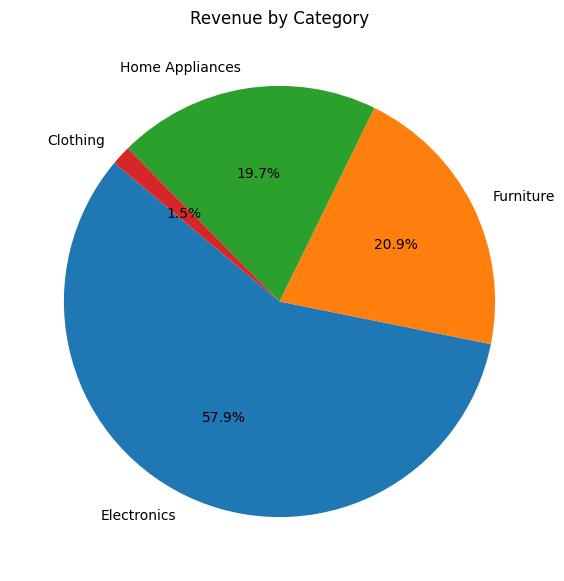

In [28]:
plt.figure(figsize=(7,7))
plt.pie(revenue_by_category['total_revenue'],
        labels=revenue_by_category['category'],
        autopct='%1.1f%%',
        startangle=140)
plt.title('Revenue by Category')
plt.show()

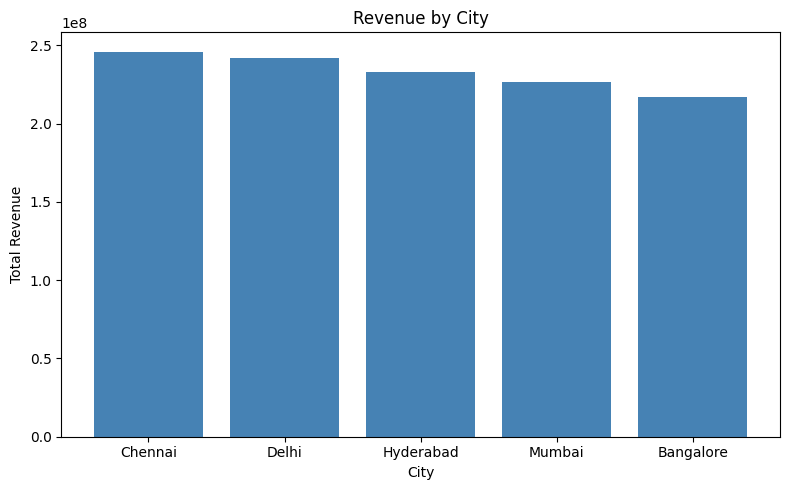

In [29]:
plt.figure(figsize=(8,5))
plt.bar(revenue_by_city['city'], revenue_by_city['total_revenue'], color='steelblue')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

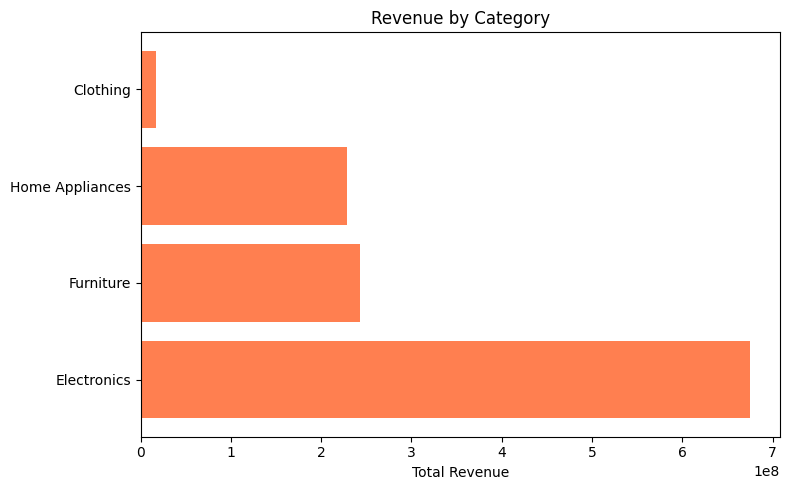

In [30]:
plt.figure(figsize=(8,5))
plt.barh(revenue_by_category['category'], revenue_by_category['total_revenue'], color='coral')
plt.title('Revenue by Category')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

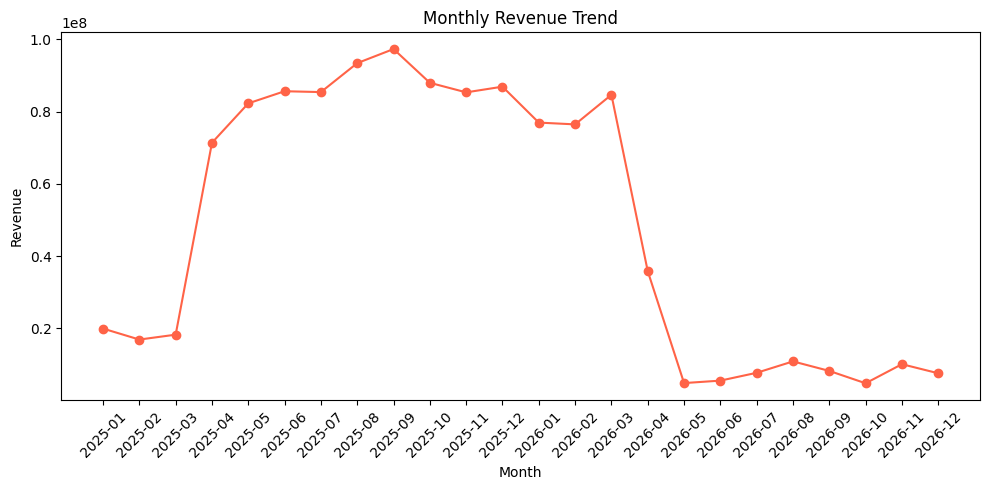

In [31]:
df['month'] = df['transaction_date'].dt.to_period('M')
monthly_revenue = df.groupby('month')['revenue'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o', color='tomato')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

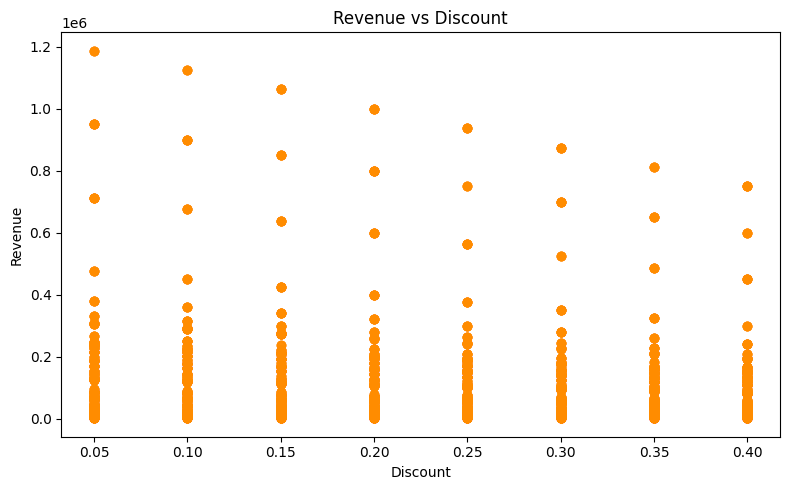

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df['discount'], df['revenue'], alpha=0.3, color='darkorange')
plt.title('Revenue vs Discount')
plt.xlabel('Discount')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

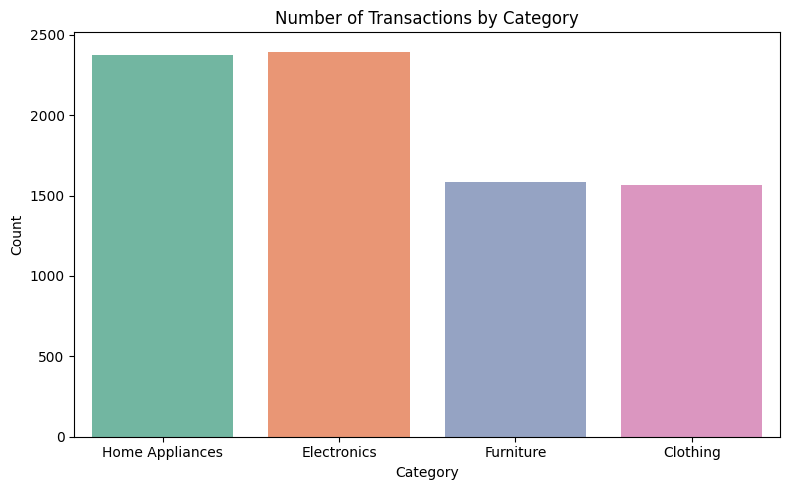

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='standard_category', hue='standard_category', palette='Set2', legend=False)
plt.title('Number of Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

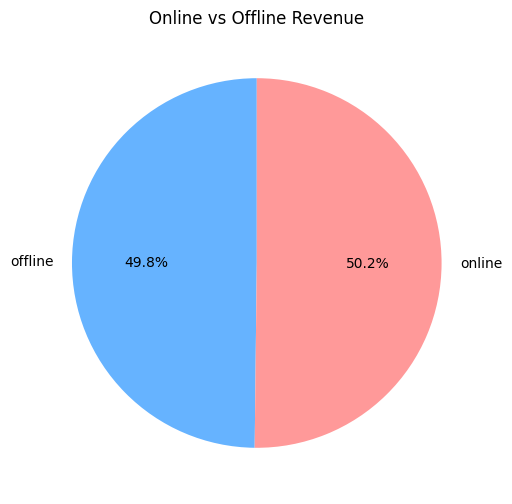

In [35]:
location_revenue = df.groupby('purchase_location')['revenue'].sum()

plt.figure(figsize=(6,6))
plt.pie(location_revenue,
        labels=location_revenue.index,
        autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'],
        startangle=90)
plt.title('Online vs Offline Revenue')
plt.show()